# Score-Based Undervalued Strategy Backtest

**Strategy:** Buy the team whose market price is below their "fair value" based on normalized score.

**Key Concept:**
- Normalize scores to 100: If Team A has 60 pts and Team B has 40 pts → A=60%, B=40%
- Compare to market price: If A is priced at 75% but their score share is 60% → A is overvalued
- Buy undervalued: The team whose price < normalized score share

**Analysis Goals:**
1. Backtest entry at every 10th of game time
2. Parameter search for stop loss, take profit, and mispricing threshold
3. Find optimal closeness/mispricing parameters

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from itertools import product
import warnings
warnings.filterwarnings('ignore')
import scipy

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

## 1. Load Price Data and Create Synthetic Score Model

Since we don't have intra-game scores in the historical Kalshi data, we'll:
1. Use the market price as a proxy for "implied score share"
2. Model the "true" score share with some noise/lag
3. Find when price diverges from this model

In [9]:
# Load raw EV data
df = pd.read_csv('../data/nba_ev_raw.csv')
print(f"Loaded {len(df):,} rows")
print(f"Unique games: {df['event_ticker'].nunique()}")
df.head()

Loaded 5,547 rows
Unique games: 155


,event_ticker,game_date,season,title,home_team,away_team,winner,minutes_until_settlement,home_mid,away_mid,favorite,favorite_price,underdog_price,favorite_won,ev_favorite,volume,settlement_delay,minutes_until_game_end
0,KXNBAGAME-26JAN26GSWMIN,2026-01-27 05:05:27.039639+00:00,2025-26,Golden State at Minnesota Winner?,Minnesota,Golden State,home,10,0.500,0.500,home,0.500,0.500,1,0.500,1071,10,0
1,KXNBAGAME-26JAN26GSWMIN,2026-01-27 05:05:27.039639+00:00,2025-26,Golden State at Minnesota Winner?,Minnesota,Golden State,home,20,0.995,0.005,home,0.995,0.005,1,0.005,2730,10,10
2,KXNBAGAME-26JAN26GSWMIN,2026-01-27 05:05:27.039639+00:00,2025-26,Golden State at Minnesota Winner?,Minnesota,Golden State,home,30,0.995,0.005,home,0.995,0.005,1,0.005,20243,10,20
3,KXNBAGAME-26JAN26GSWMIN,2026-01-27 05:05:27.039639+00:00,2025-26,Golden State at Minnesota Winner?,Minnesota,Golden State,home,40,0.995,0.005,home,0.995,0.005,1,0.005,7281,10,30
4,KXNBAGAME-26JAN26GSWMIN,2026-01-27 05:05:27.039639+00:00,2025-26,Golden State at Minnesota Winner?,Minnesota,Golden State,home,50,0.965,0.035,home,0.965,0.035,1,0.035,43945,10,40


In [10]:
# Prepare data
TOTAL_GAME_MINUTES = 48

# Create game_pct: what % of game has elapsed
df['game_pct'] = 100 * (1 - df['minutes_until_game_end'] / TOTAL_GAME_MINUTES)
df['game_pct'] = df['game_pct'].clip(0, 100)
df['game_decile'] = (df['game_pct'] // 10).astype(int).clip(0, 9)

# Home probability is home_mid
df['home_prob'] = df['home_mid']
df['away_prob'] = df['away_mid']

print(f"Game % range: {df['game_pct'].min():.1f}% to {df['game_pct'].max():.1f}%")

Game % range: 0.0% to 100.0%


## 2. Model "Fair Value" from Score

We'll use an empirical model: at any point in the game, the "fair" win probability should be based on:
1. Current score differential
2. Time remaining
3. Historical comeback rates

For NBA, a reasonable model is:
- `fair_prob = sigmoid(score_diff / volatility_factor * sqrt(time_remaining))`

We'll estimate the score differential from price movements and look for divergences.

In [11]:
from scipy.special import logit, expit

def estimate_score_share_from_price(price: float, game_pct: float, vol_factor: float = 15.0) -> float:
    """
    Reverse-engineer implied score differential from market price.
    
    Model: price = sigmoid(score_diff / (vol * sqrt(time_remaining)))
    Therefore: score_diff = logit(price) * vol * sqrt(time_remaining)
    
    Then normalize to score_share = score / (score + opponent_score)
    Assuming total ~200 points at end, scale appropriately.
    """
    # Clamp price to avoid log(0)
    price = np.clip(price, 0.01, 0.99)
    
    # Time remaining as fraction
    time_remaining = max(0.01, 1 - game_pct / 100)
    
    # Implied score differential (in "standard units")
    implied_diff = logit(price) * vol_factor * np.sqrt(time_remaining)
    
    # Convert to score share assuming average ~100 pts per team at end
    # If diff = 0, share = 50%. If diff = 20, share ≈ 60%
    total_expected = 200 * (game_pct / 100)  # Points scored so far
    my_score = (total_expected / 2) + implied_diff / 2
    opp_score = (total_expected / 2) - implied_diff / 2
    
    if my_score + opp_score <= 0:
        return 0.5
    
    return my_score / (my_score + opp_score)

# Test
for pct in [25, 50, 75, 90]:
    for price in [0.3, 0.5, 0.7]:
        share = estimate_score_share_from_price(price, pct)
        print(f"Game {pct}%, Price {price:.0%} → Implied Score Share: {share:.1%}")

Game 25%, Price 30% → Implied Score Share: 39.0%
Game 25%, Price 50% → Implied Score Share: 50.0%
Game 25%, Price 70% → Implied Score Share: 61.0%
Game 50%, Price 30% → Implied Score Share: 45.5%
Game 50%, Price 50% → Implied Score Share: 50.0%
Game 50%, Price 70% → Implied Score Share: 54.5%
Game 75%, Price 30% → Implied Score Share: 47.9%
Game 75%, Price 50% → Implied Score Share: 50.0%
Game 75%, Price 70% → Implied Score Share: 52.1%
Game 90%, Price 30% → Implied Score Share: 48.9%
Game 90%, Price 50% → Implied Score Share: 50.0%
Game 90%, Price 70% → Implied Score Share: 51.1%


In [12]:
# Calculate implied score share for all rows
df['home_score_share'] = df.apply(
    lambda r: estimate_score_share_from_price(r['home_prob'], r['game_pct']),
    axis=1
)

# The "mispricing" is when price differs from score-implied fair value
# If home_prob > home_score_share, home is overpriced (away is undervalued)
# If home_prob < home_score_share, home is underpriced (home is undervalued)

df['home_mispricing'] = df['home_prob'] - df['home_score_share']  # Positive = home overpriced
df['away_mispricing'] = -df['home_mispricing']  # Positive = away overpriced

print("Mispricing distribution:")
df['home_mispricing'].describe()

Mispricing distribution:


count    5547.000000
mean        0.049267
std         0.219506
min        -0.495000
25%        -0.105000
50%         0.055000
75%         0.215000
max         0.495000
Name: home_mispricing, dtype: float64

## 3. Alternative: Use Price Momentum as Proxy for Score

Another approach: if the price moved a lot recently, the market may be "overreacting".
We look for mean reversion opportunities.

In [13]:
@dataclass
class GameTrajectory:
    """Full price trajectory for a single game."""
    event_ticker: str
    home_team: str
    away_team: str
    home_won: bool
    # Dict mapping game_pct to data
    snapshots: Dict[int, Dict[str, float]] = field(default_factory=dict)

def build_trajectories(df: pd.DataFrame) -> List[GameTrajectory]:
    """Build price trajectories for each game."""
    trajectories = []
    
    for event_ticker, group in df.groupby('event_ticker'):
        group = group.sort_values('game_pct')
        first = group.iloc[0]
        
        # Determine winner
        home_won = (first['winner'] == 'home') if 'winner' in first else \
                   (first['favorite'] == 'home' and first['favorite_won']) or \
                   (first['favorite'] == 'away' and not first['favorite_won'])
        
        snapshots = {}
        for _, row in group.iterrows():
            pct = int(row['game_pct'])
            snapshots[pct] = {
                'home_prob': row['home_prob'],
                'away_prob': row['away_prob'],
                'home_score_share': row['home_score_share'],
                'home_mispricing': row['home_mispricing'],
            }
        
        traj = GameTrajectory(
            event_ticker=event_ticker,
            home_team=first['home_team'],
            away_team=first['away_team'],
            home_won=home_won,
            snapshots=snapshots,
        )
        trajectories.append(traj)
    
    return trajectories

trajectories = build_trajectories(df)
print(f"Built {len(trajectories)} game trajectories")

Built 155 game trajectories


In [14]:
# Example trajectory
t = trajectories[0]
print(f"Game: {t.away_team} @ {t.home_team}")
print(f"Home won: {t.home_won}")
print(f"\nSample snapshots:")
for pct in sorted(t.snapshots.keys())[::5][:8]:
    s = t.snapshots[pct]
    print(f"  {pct:3d}%: home_prob={s['home_prob']:.3f} score_share={s['home_score_share']:.3f} mispricing={s['home_mispricing']:+.3f}")

Game: Cleveland @ Indiana
Home won: False

Sample snapshots:
    0%: home_prob=0.335 score_share=0.500 mispricing=-0.165
  100%: home_prob=0.500 score_share=0.500 mispricing=+0.000


## 4. Simulate "Buy Undervalued" Strategy

In [15]:
@dataclass
class TradeResult:
    """Result of a single simulated trade."""
    event_ticker: str
    entry_pct: int
    side: str  # 'home' or 'away'
    entry_price: float
    exit_pct: int
    exit_price: float
    exit_reason: str
    won: bool
    pnl: float
    mispricing_at_entry: float  # How undervalued was it?


def simulate_undervalued_trade(
    traj: GameTrajectory,
    entry_pct: int,
    min_mispricing: float,  # Min undervaluation to enter (e.g., 0.05 = 5% underpriced)
    stop_loss: float,
    take_profit: float,
    fee_rate: float = 0.07,
) -> Optional[TradeResult]:
    """
    Simulate buying the undervalued team.
    
    Undervalued = price < score-implied fair value
    If home_mispricing > 0, home is OVERpriced, so away is undervalued.
    If home_mispricing < 0, home is UNDERpriced, so home is undervalued.
    """
    
    # Get entry snapshot
    if entry_pct not in traj.snapshots:
        available = sorted(traj.snapshots.keys())
        closest = min(available, key=lambda x: abs(x - entry_pct))
        if abs(closest - entry_pct) > 5:
            return None
        entry_pct = closest
    
    entry_snap = traj.snapshots[entry_pct]
    home_mispricing = entry_snap['home_mispricing']
    
    # Determine which side is undervalued
    # home_mispricing > 0 means home is OVERpriced → away is undervalued
    # home_mispricing < 0 means home is UNDERpriced → home is undervalued
    
    if home_mispricing > min_mispricing:
        # Away is undervalued (home is overpriced by min_mispricing)
        side = 'away'
        entry_price = entry_snap['away_prob']
        mispricing = home_mispricing  # Positive = away is undervalued
        won = not traj.home_won
    elif home_mispricing < -min_mispricing:
        # Home is undervalued (home is underpriced by min_mispricing)
        side = 'home'
        entry_price = entry_snap['home_prob']
        mispricing = -home_mispricing  # Flip sign so positive = undervalued
        won = traj.home_won
    else:
        # No significant mispricing, skip
        return None
    
    # Calculate stop/take levels
    stop_price = entry_price * (1 - stop_loss)
    take_price = entry_price * (1 + take_profit)
    
    # Walk through remaining game
    exit_pct = 100
    exit_price = 1.0 if won else 0.0
    exit_reason = 'settlement'
    
    for pct in sorted(traj.snapshots.keys()):
        if pct <= entry_pct:
            continue
        
        snap = traj.snapshots[pct]
        current_price = snap['home_prob'] if side == 'home' else snap['away_prob']
        
        if current_price <= stop_price:
            exit_pct = pct
            exit_price = current_price
            exit_reason = 'stop_loss'
            break
        
        if current_price >= take_price:
            exit_pct = pct
            exit_price = current_price
            exit_reason = 'take_profit'
            break
    
    # Calculate P&L
    raw_pnl = exit_price - entry_price
    pnl = raw_pnl * (1 - fee_rate) if raw_pnl > 0 else raw_pnl
    
    return TradeResult(
        event_ticker=traj.event_ticker,
        entry_pct=entry_pct,
        side=side,
        entry_price=entry_price,
        exit_pct=exit_pct,
        exit_price=exit_price,
        exit_reason=exit_reason,
        won=won,
        pnl=pnl,
        mispricing_at_entry=mispricing,
    )

# Test
result = simulate_undervalued_trade(trajectories[0], entry_pct=30, min_mispricing=0.03, stop_loss=0.10, take_profit=0.15)
if result:
    print(f"Side: {result.side}")
    print(f"Entry: {result.entry_pct}% @ ${result.entry_price:.3f} (mispricing={result.mispricing_at_entry:+.1%})")
    print(f"Exit: {result.exit_pct}% @ ${result.exit_price:.3f} ({result.exit_reason})")
    print(f"P&L: ${result.pnl:.3f}")
else:
    print("No trade signal (mispricing below threshold)")

No trade signal (mispricing below threshold)


## 5. Full Parameter Sweep

In [16]:
# Parameter grid
ENTRY_PCTS = list(range(0, 100, 10))  # 0%, 10%, 20%, ... 90%
MIN_MISPRICINGS = [0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15]  # Min undervaluation to trade
STOP_LOSSES = [0.05, 0.10, 0.15, 0.20, 0.30, 1.0]  # Stop loss %
TAKE_PROFITS = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 1.0]  # Take profit %

print(f"Parameter grid:")
print(f"  Entry points: {ENTRY_PCTS}")
print(f"  Min mispricing: {MIN_MISPRICINGS}")
print(f"  Stop losses: {STOP_LOSSES}")
print(f"  Take profits: {TAKE_PROFITS}")
print(f"\nTotal combinations: {len(ENTRY_PCTS) * len(MIN_MISPRICINGS) * len(STOP_LOSSES) * len(TAKE_PROFITS):,}")

Parameter grid:
  Entry points: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
  Min mispricing: [0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15]
  Stop losses: [0.05, 0.1, 0.15, 0.2, 0.3, 1.0]
  Take profits: [0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 1.0]

Total combinations: 2,940


In [17]:
def run_backtest(
    trajectories: List[GameTrajectory],
    entry_pct: int,
    min_mispricing: float,
    stop_loss: float,
    take_profit: float,
) -> Dict[str, float]:
    """Run backtest with given parameters."""
    
    trades = []
    for traj in trajectories:
        result = simulate_undervalued_trade(
            traj, entry_pct, min_mispricing, stop_loss, take_profit
        )
        if result:
            trades.append(result)
    
    if not trades:
        return {
            'n_trades': 0,
            'total_pnl': 0,
            'avg_pnl': 0,
            'win_rate': 0,
            'sharpe': 0,
            'avg_mispricing': 0,
        }
    
    pnls = [t.pnl for t in trades]
    wins = sum(1 for t in trades if t.pnl > 0)
    
    return {
        'n_trades': len(trades),
        'total_pnl': sum(pnls),
        'avg_pnl': np.mean(pnls),
        'win_rate': wins / len(trades),
        'sharpe': np.mean(pnls) / np.std(pnls) if np.std(pnls) > 0 else 0,
        'avg_mispricing': np.mean([t.mispricing_at_entry for t in trades]),
    }

# Quick test
result = run_backtest(trajectories, entry_pct=30, min_mispricing=0.05, stop_loss=0.10, take_profit=0.15)
print(f"Test results:")
for k, v in result.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Test results:
  n_trades: 0
  total_pnl: 0
  avg_pnl: 0
  win_rate: 0
  sharpe: 0
  avg_mispricing: 0


In [18]:
# Full parameter sweep
results = []
total = len(ENTRY_PCTS) * len(MIN_MISPRICINGS) * len(STOP_LOSSES) * len(TAKE_PROFITS)
i = 0

for entry_pct in ENTRY_PCTS:
    for min_mispricing in MIN_MISPRICINGS:
        for stop_loss in STOP_LOSSES:
            for take_profit in TAKE_PROFITS:
                i += 1
                if i % 500 == 0:
                    print(f"Progress: {i}/{total} ({100*i/total:.1f}%)")
                
                stats = run_backtest(
                    trajectories,
                    entry_pct=entry_pct,
                    min_mispricing=min_mispricing,
                    stop_loss=stop_loss,
                    take_profit=take_profit,
                )
                
                results.append({
                    'entry_pct': entry_pct,
                    'min_mispricing': min_mispricing,
                    'stop_loss': stop_loss,
                    'take_profit': take_profit,
                    **stats,
                })

results_df = pd.DataFrame(results)
print(f"\n✅ Completed {len(results_df):,} parameter combinations")
results_df.head()

Progress: 500/2940 (17.0%)
Progress: 1000/2940 (34.0%)
Progress: 1500/2940 (51.0%)
Progress: 2000/2940 (68.0%)
Progress: 2500/2940 (85.0%)

✅ Completed 2,940 parameter combinations


,entry_pct,min_mispricing,stop_loss,take_profit,n_trades,total_pnl,avg_pnl,win_rate,sharpe,avg_mispricing
0,0,0.01,0.05,0.05,151,0.26830,0.001777,0.430464,0.006162,0.167848
1,0,0.01,0.05,0.10,151,-0.07960,-0.000527,0.423841,-0.001821,0.167848
2,0,0.01,0.05,0.15,151,-0.57365,-0.003799,0.410596,-0.013080,0.167848
3,0,0.01,0.05,0.20,151,-1.00525,-0.006657,0.397351,-0.022883,0.167848
4,0,0.01,0.05,0.30,151,-1.06010,-0.007021,0.377483,-0.023793,0.167848


## 6. Analyze Results by Entry Time

In [19]:
print("=" * 80)
print("OPTIMAL PARAMETERS BY ENTRY TIME")
print("=" * 80)

best_by_entry = []
for entry_pct in ENTRY_PCTS:
    subset = results_df[results_df['entry_pct'] == entry_pct]
    subset = subset[subset['n_trades'] >= 5]
    
    if len(subset) == 0:
        continue
    
    best = subset.loc[subset['sharpe'].idxmax()]
    best_by_entry.append(best)
    
    print(f"\n📍 Entry at {entry_pct}% of game:")
    print(f"   Best params: mispricing≥{best['min_mispricing']:.0%}, SL={best['stop_loss']:.0%}, TP={best['take_profit']:.0%}")
    print(f"   Trades: {best['n_trades']:.0f}, Win rate: {best['win_rate']:.1%}")
    print(f"   Avg PnL: {best['avg_pnl']*100:.2f}¢, Sharpe: {best['sharpe']:.3f}")

best_by_entry_df = pd.DataFrame(best_by_entry)

OPTIMAL PARAMETERS BY ENTRY TIME

📍 Entry at 0% of game:
   Best params: mispricing≥15%, SL=100%, TP=50%
   Trades: 74, Win rate: 79.7%
   Avg PnL: 20.39¢, Sharpe: 0.756

📍 Entry at 20% of game:
   Best params: mispricing≥15%, SL=100%, TP=5%
   Trades: 37, Win rate: 100.0%
   Avg PnL: 2.21¢, Sharpe: 1.739

📍 Entry at 40% of game:
   Best params: mispricing≥15%, SL=100%, TP=15%
   Trades: 92, Win rate: 78.3%
   Avg PnL: 19.44¢, Sharpe: 0.990

📍 Entry at 60% of game:
   Best params: mispricing≥15%, SL=100%, TP=5%
   Trades: 118, Win rate: 69.5%
   Avg PnL: 23.34¢, Sharpe: 1.041

📍 Entry at 80% of game:
   Best params: mispricing≥15%, SL=5%, TP=5%
   Trades: 139, Win rate: 66.2%
   Avg PnL: 27.48¢, Sharpe: 1.148


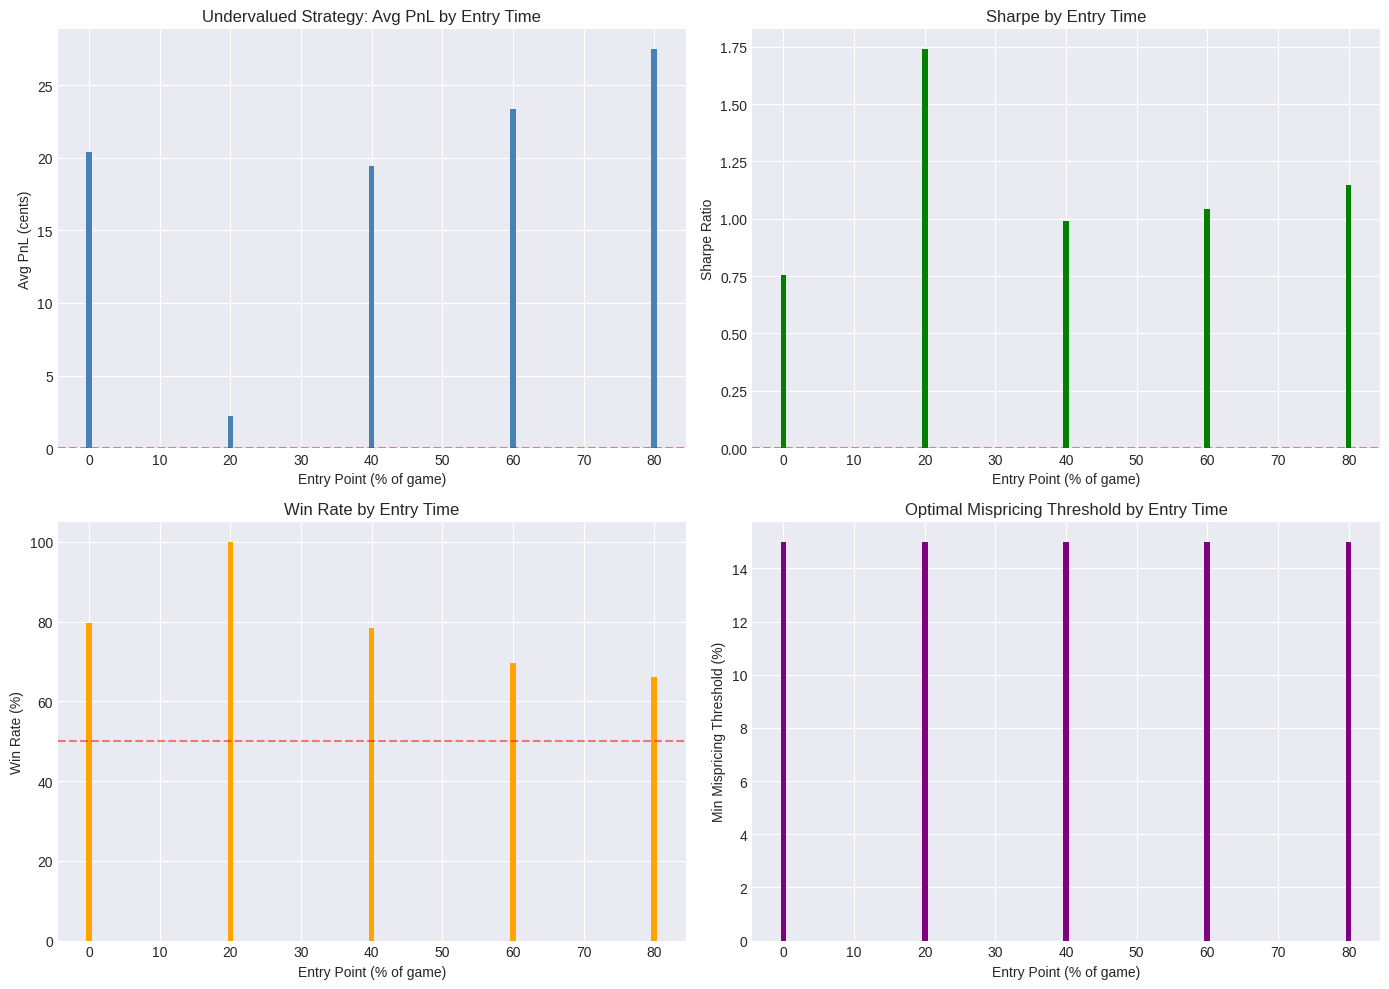

In [20]:
# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.bar(best_by_entry_df['entry_pct'], best_by_entry_df['avg_pnl'] * 100, color='steelblue')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Entry Point (% of game)')
ax.set_ylabel('Avg PnL (cents)')
ax.set_title('Undervalued Strategy: Avg PnL by Entry Time')

ax = axes[0, 1]
ax.bar(best_by_entry_df['entry_pct'], best_by_entry_df['sharpe'], color='green')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Entry Point (% of game)')
ax.set_ylabel('Sharpe Ratio')
ax.set_title('Sharpe by Entry Time')

ax = axes[1, 0]
ax.bar(best_by_entry_df['entry_pct'], best_by_entry_df['win_rate'] * 100, color='orange')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Entry Point (% of game)')
ax.set_ylabel('Win Rate (%)')
ax.set_title('Win Rate by Entry Time')

ax = axes[1, 1]
ax.bar(best_by_entry_df['entry_pct'], best_by_entry_df['min_mispricing'] * 100, color='purple')
ax.set_xlabel('Entry Point (% of game)')
ax.set_ylabel('Min Mispricing Threshold (%)')
ax.set_title('Optimal Mispricing Threshold by Entry Time')

plt.tight_layout()
plt.show()

## 7. Heatmaps: Mispricing vs Stop/Take

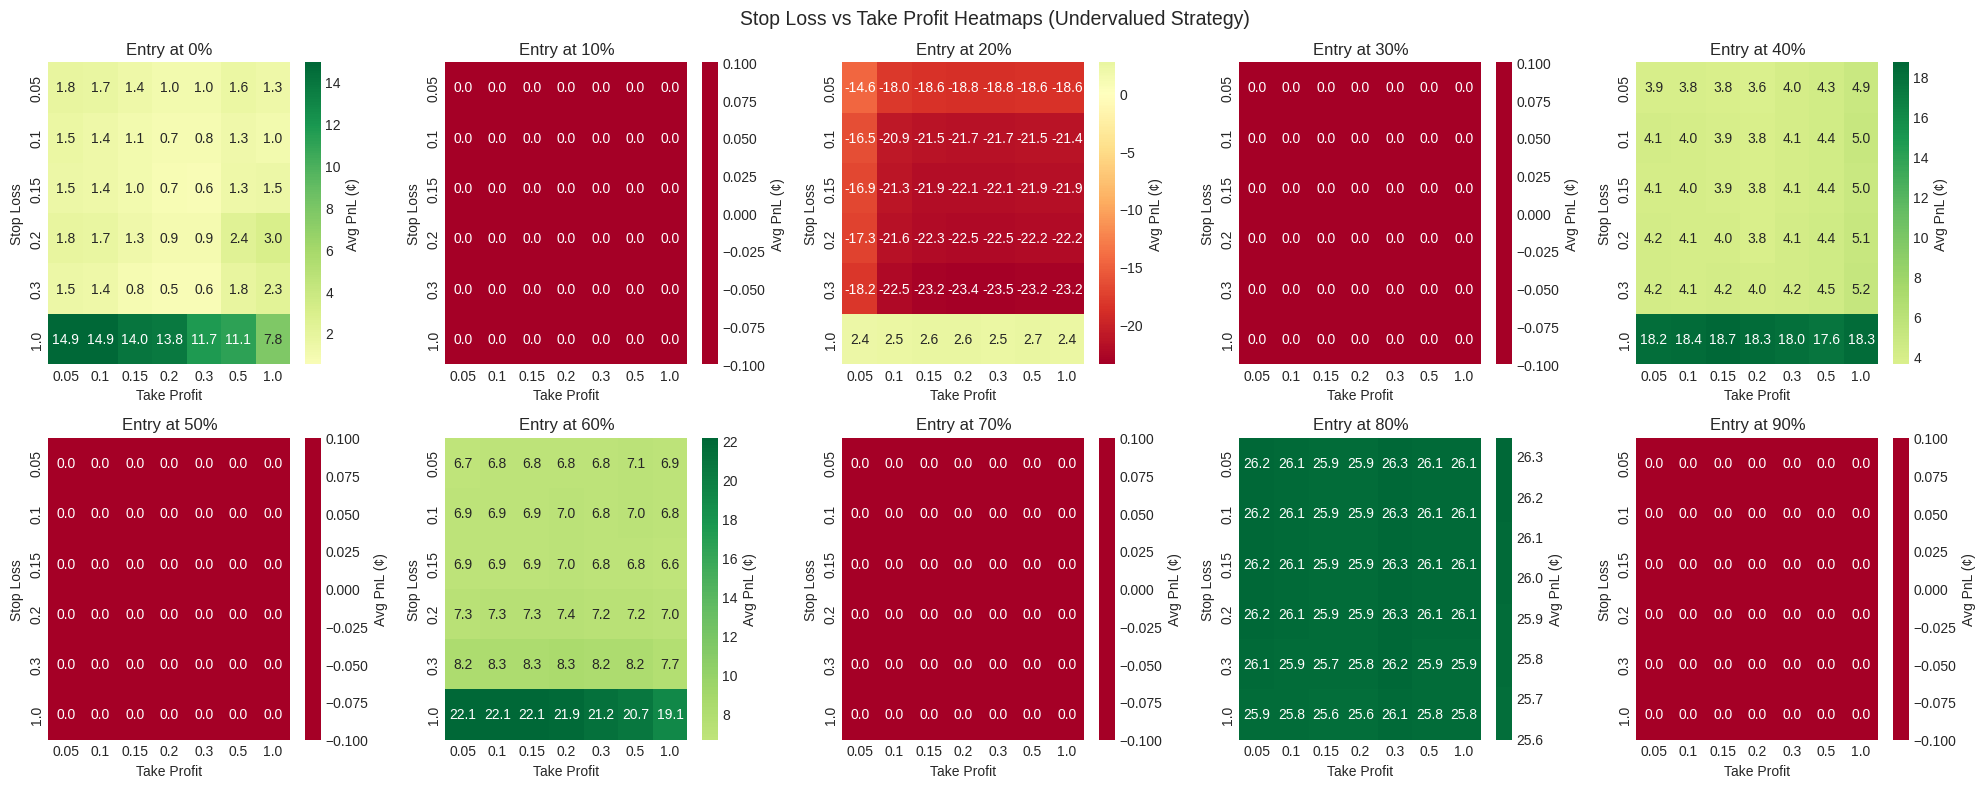

In [21]:
# Heatmap: Stop Loss vs Take Profit (aggregated over all params)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, entry_pct in enumerate(ENTRY_PCTS):
    subset = results_df[results_df['entry_pct'] == entry_pct]
    pivot = subset.groupby(['stop_loss', 'take_profit'])['avg_pnl'].mean().unstack()
    
    ax = axes[idx]
    sns.heatmap(pivot * 100, annot=True, fmt='.1f', cmap='RdYlGn', center=0, 
                ax=ax, cbar_kws={'label': 'Avg PnL (¢)'})
    ax.set_title(f'Entry at {entry_pct}%')
    ax.set_xlabel('Take Profit')
    ax.set_ylabel('Stop Loss')

plt.suptitle('Stop Loss vs Take Profit Heatmaps (Undervalued Strategy)', fontsize=14)
plt.tight_layout()
plt.show()

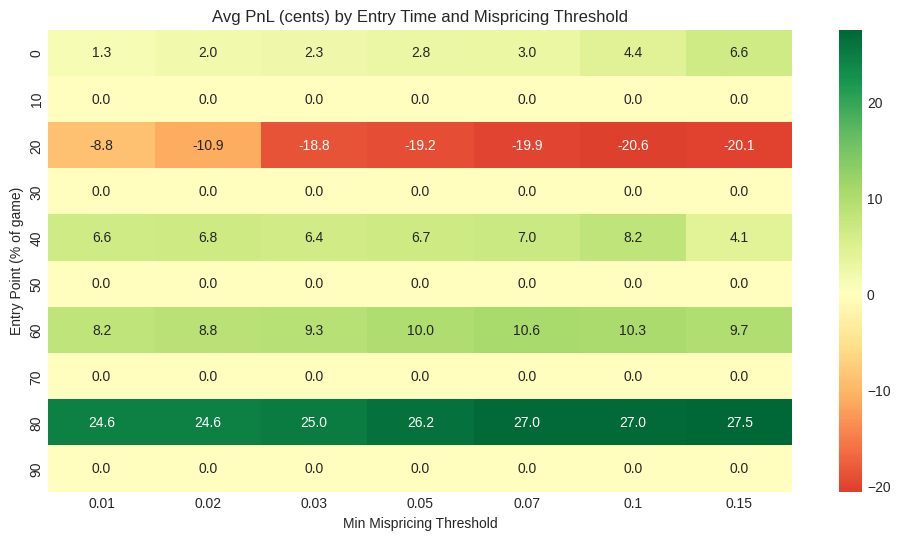

In [22]:
# Heatmap: Entry Time vs Mispricing Threshold
pivot_mispricing = results_df.pivot_table(
    values='avg_pnl',
    index='entry_pct',
    columns='min_mispricing',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_mispricing * 100, annot=True, fmt='.1f', cmap='RdYlGn', center=0)
plt.xlabel('Min Mispricing Threshold')
plt.ylabel('Entry Point (% of game)')
plt.title('Avg PnL (cents) by Entry Time and Mispricing Threshold')
plt.show()

## 8. Mispricing Threshold Analysis

MISPRICING THRESHOLD ANALYSIS (Aggregated)
                n_trades  avg_pnl  win_rate  sharpe  avg_mispricing
min_mispricing                                                     
0.01                74.2   0.0318    0.2421  0.1184          0.1033
0.02                69.8   0.0313    0.2421  0.1172          0.1077
0.03                64.4   0.0242    0.2428  0.0842          0.1170
0.05                62.2   0.0266    0.2445  0.0994          0.1205
0.07                59.1   0.0278    0.2447  0.1091          0.1256
0.10                54.9   0.0294    0.2452  0.1436          0.1322
0.15                46.0   0.0278    0.2411  0.1479          0.1434


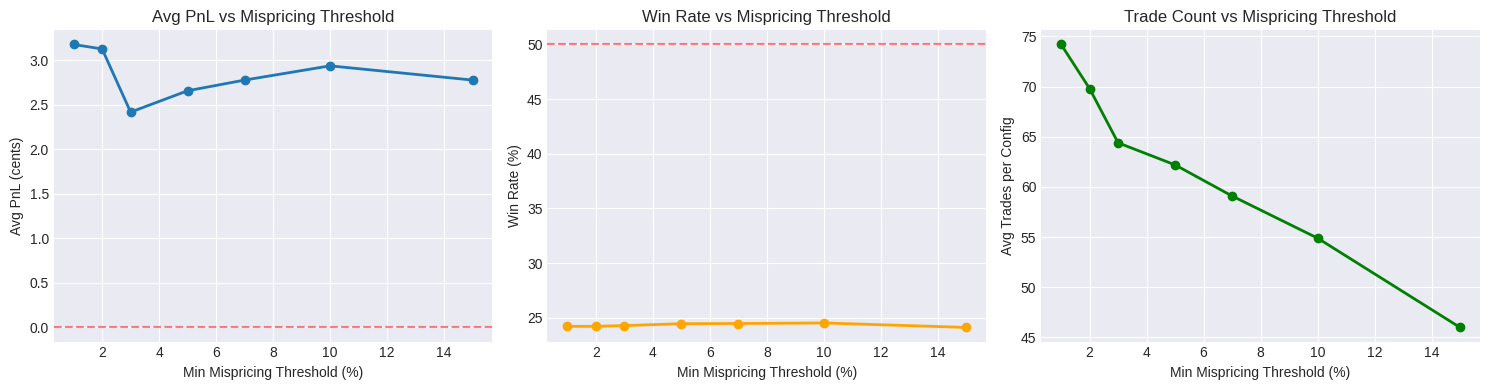

In [23]:
print("=" * 80)
print("MISPRICING THRESHOLD ANALYSIS (Aggregated)")
print("=" * 80)

mispricing_agg = results_df.groupby('min_mispricing').agg({
    'n_trades': 'mean',
    'avg_pnl': 'mean',
    'win_rate': 'mean',
    'sharpe': 'mean',
    'avg_mispricing': 'mean',
}).round(4)

print(mispricing_agg)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(mispricing_agg.index * 100, mispricing_agg['avg_pnl'] * 100, 'o-', linewidth=2)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Min Mispricing Threshold (%)')
ax.set_ylabel('Avg PnL (cents)')
ax.set_title('Avg PnL vs Mispricing Threshold')

ax = axes[1]
ax.plot(mispricing_agg.index * 100, mispricing_agg['win_rate'] * 100, 'o-', linewidth=2, color='orange')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Min Mispricing Threshold (%)')
ax.set_ylabel('Win Rate (%)')
ax.set_title('Win Rate vs Mispricing Threshold')

ax = axes[2]
ax.plot(mispricing_agg.index * 100, mispricing_agg['n_trades'], 'o-', linewidth=2, color='green')
ax.set_xlabel('Min Mispricing Threshold (%)')
ax.set_ylabel('Avg Trades per Config')
ax.set_title('Trade Count vs Mispricing Threshold')

plt.tight_layout()
plt.show()

## 9. Top Parameter Combinations

In [24]:
valid = results_df[results_df['n_trades'] >= 10]

print("=" * 80)
print("TOP 20 PARAMETER COMBINATIONS (by Sharpe Ratio)")
print("=" * 80)

top_20 = valid.nlargest(20, 'sharpe')[[
    'entry_pct', 'min_mispricing', 'stop_loss', 'take_profit',
    'n_trades', 'avg_pnl', 'win_rate', 'sharpe'
]].copy()
top_20['avg_pnl_cents'] = top_20['avg_pnl'] * 100
top_20['win_rate_pct'] = top_20['win_rate'] * 100
print(top_20.to_string())

TOP 20 PARAMETER COMBINATIONS (by Sharpe Ratio)
      entry_pct  min_mispricing  stop_loss  take_profit  n_trades   avg_pnl  win_rate    sharpe  avg_pnl_cents  win_rate_pct
875          20            0.15       1.00         0.05        37  0.022119  1.000000  1.739083       2.211892     100.00000
876          20            0.15       1.00         0.10        37  0.022119  1.000000  1.739083       2.211892     100.00000
877          20            0.15       1.00         0.15        37  0.022119  1.000000  1.739083       2.211892     100.00000
878          20            0.15       1.00         0.20        37  0.022119  1.000000  1.739083       2.211892     100.00000
879          20            0.15       1.00         0.30        37  0.022119  1.000000  1.739083       2.211892     100.00000
880          20            0.15       1.00         0.50        37  0.022119  1.000000  1.739083       2.211892     100.00000
881          20            0.15       1.00         1.00        37  0.022119  

In [25]:
print("\n" + "=" * 80)
print("TOP 20 PARAMETER COMBINATIONS (by Total PnL)")
print("=" * 80)

top_pnl = valid.nlargest(20, 'total_pnl')[[
    'entry_pct', 'min_mispricing', 'stop_loss', 'take_profit',
    'n_trades', 'total_pnl', 'avg_pnl', 'win_rate', 'sharpe'
]]
print(top_pnl.to_string())


TOP 20 PARAMETER COMBINATIONS (by Total PnL)
      entry_pct  min_mispricing  stop_loss  take_profit  n_trades  total_pnl   avg_pnl  win_rate    sharpe
2524         80            0.07       0.05          0.3       146   40.26895  0.275815  0.664384  1.116120
2531         80            0.07       0.10          0.3       146   40.26895  0.275815  0.664384  1.116120
2538         80            0.07       0.15          0.3       146   40.26895  0.275815  0.664384  1.116120
2545         80            0.07       0.20          0.3       146   40.26895  0.275815  0.664384  1.116120
2552         80            0.07       0.30          0.3       146   40.03395  0.274205  0.664384  1.096041
2482         80            0.05       0.05          0.3       149   39.92405  0.267947  0.657718  1.034852
2489         80            0.05       0.10          0.3       149   39.92405  0.267947  0.657718  1.034852
2496         80            0.05       0.15          0.3       149   39.92405  0.267947  0.657718  

## Simple Strategy: Buy Underdog at Game Start Every Time

In [27]:
# Simple backtest: Buy underdog at game start, hold to settlement
print("=" * 80)
print("SIMPLE STRATEGY: BUY UNDERDOG AT GAME START")
print("=" * 80)

# Get underdog info at game start (0% of game)
underdog_trades = []

for traj in trajectories:
    # Find earliest snapshot
    if not traj.snapshots:
        continue
    
    start_pct = min(traj.snapshots.keys())
    snap = traj.snapshots[start_pct]
    
    home_prob = snap['home_prob']
    away_prob = snap['away_prob']
    
    # Underdog is the team with lower price
    if home_prob < away_prob:
        underdog_side = 'home'
        underdog_price = home_prob
        underdog_won = traj.home_won
    else:
        underdog_side = 'away'
        underdog_price = away_prob
        underdog_won = not traj.home_won
    
    # Calculate PnL (hold to settlement)
    exit_price = 1.0 if underdog_won else 0.0
    raw_pnl = exit_price - underdog_price
    fee_rate = 0.07
    pnl = raw_pnl * (1 - fee_rate) if raw_pnl > 0 else raw_pnl
    
    underdog_trades.append({
        'event_ticker': traj.event_ticker,
        'home_team': traj.home_team,
        'away_team': traj.away_team,
        'underdog_side': underdog_side,
        'underdog_price': underdog_price,
        'underdog_won': underdog_won,
        'pnl': pnl,
        'raw_pnl': raw_pnl,
    })

underdog_df = pd.DataFrame(underdog_trades)
print(f"\nTotal games: {len(underdog_df)}")
print(f"Underdog win rate: {underdog_df['underdog_won'].mean():.1%}")
print(f"\n--- P&L Statistics ---")
print(f"Total PnL: ${underdog_df['pnl'].sum():.2f}")
print(f"Avg PnL per trade: {underdog_df['pnl'].mean()*100:.2f} cents")
print(f"Median PnL: {underdog_df['pnl'].median()*100:.2f} cents")
print(f"Std Dev: {underdog_df['pnl'].std()*100:.2f} cents")
print(f"Sharpe Ratio: {underdog_df['pnl'].mean() / underdog_df['pnl'].std():.3f}")
print(f"\n--- Price Statistics ---")
print(f"Avg underdog price: {underdog_df['underdog_price'].mean():.1%}")
print(f"Median underdog price: {underdog_df['underdog_price'].median():.1%}")

SIMPLE STRATEGY: BUY UNDERDOG AT GAME START

Total games: 155
Underdog win rate: 34.8%

--- P&L Statistics ---
Total PnL: $-0.96
Avg PnL per trade: -0.62 cents
Median PnL: -23.50 cents
Std Dev: 45.55 cents
Sharpe Ratio: -0.014

--- Price Statistics ---
Avg underdog price: 33.9%
Median underdog price: 35.5%



--- EV by Underdog Price Bucket ---
              n_trades  avg_pnl  total_pnl  win_rate  avg_price  ev_cents
price_bucket                                                             
0-15%               11  -0.0493    -0.5420    0.0909     0.1345     -4.93
15-25%              27   0.1106     2.9861    0.3333     0.2039     11.06
25-35%              37   0.0501     1.8531    0.3784     0.3100      5.01
35-45%              58  -0.0744    -4.3172    0.3448     0.4051     -7.44
45-50%              21  -0.0666    -1.3976    0.4286     0.4795     -6.66


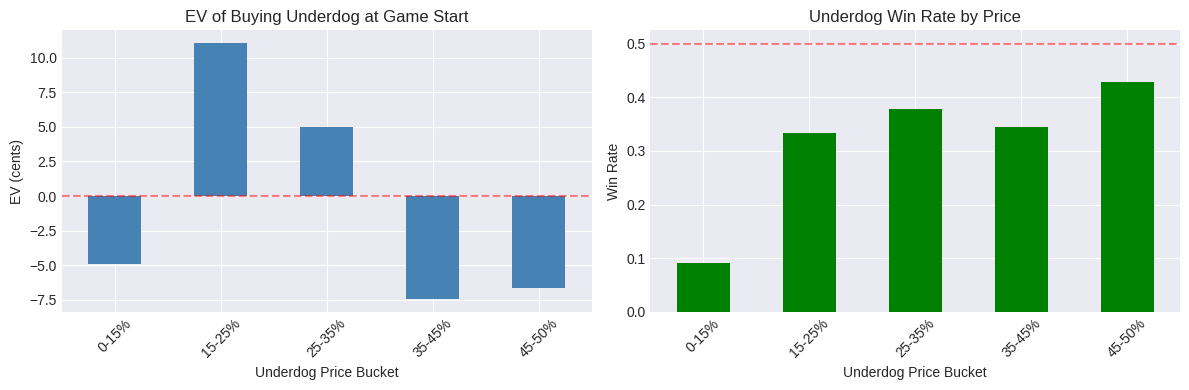

In [28]:
# Breakdown by underdog price bucket
print("\n--- EV by Underdog Price Bucket ---")
underdog_df['price_bucket'] = pd.cut(underdog_df['underdog_price'], 
                                      bins=[0, 0.15, 0.25, 0.35, 0.45, 0.50],
                                      labels=['0-15%', '15-25%', '25-35%', '35-45%', '45-50%'])

bucket_stats = underdog_df.groupby('price_bucket', observed=True).agg({
    'pnl': ['count', 'mean', 'sum'],
    'underdog_won': 'mean',
    'underdog_price': 'mean',
}).round(4)
bucket_stats.columns = ['n_trades', 'avg_pnl', 'total_pnl', 'win_rate', 'avg_price']
bucket_stats['ev_cents'] = bucket_stats['avg_pnl'] * 100
print(bucket_stats)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
bucket_stats['ev_cents'].plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Underdog Price Bucket')
ax.set_ylabel('EV (cents)')
ax.set_title('EV of Buying Underdog at Game Start')
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
bucket_stats['win_rate'].plot(kind='bar', ax=ax, color='green')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50%')
ax.set_xlabel('Underdog Price Bucket')
ax.set_ylabel('Win Rate')
ax.set_title('Underdog Win Rate by Price')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

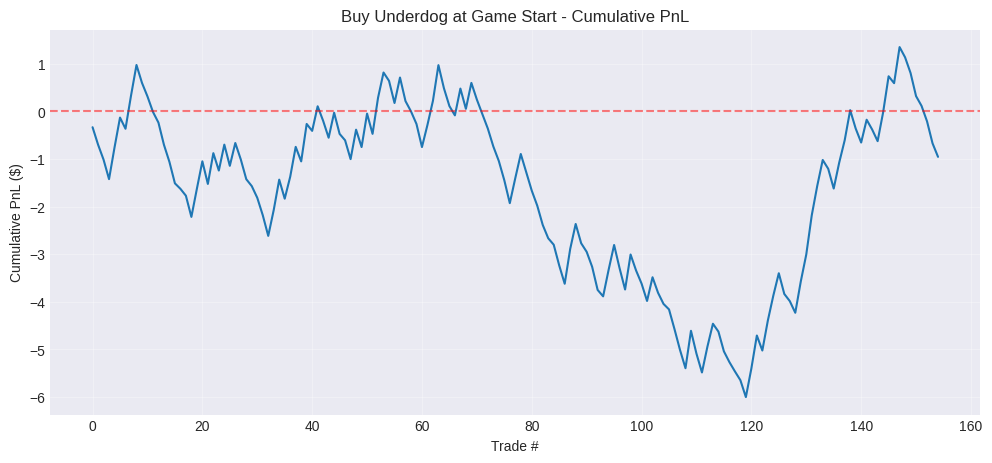


SUMMARY: BUY UNDERDOG AT GAME START
Strategy: Buy underdog (lower-priced team) at game start, hold to settlement
Games: 155
Win Rate: 34.8%
Avg Entry Price: 33.9%
EV per trade: -0.62 cents
Total PnL: $-0.96


In [29]:
# Cumulative PnL over time
underdog_df['cumulative_pnl'] = underdog_df['pnl'].cumsum()

plt.figure(figsize=(12, 5))
plt.plot(underdog_df['cumulative_pnl'], linewidth=1.5)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Trade #')
plt.ylabel('Cumulative PnL ($)')
plt.title('Buy Underdog at Game Start - Cumulative PnL')
plt.grid(True, alpha=0.3)
plt.show()

# Summary
print(f"\n{'='*60}")
print("SUMMARY: BUY UNDERDOG AT GAME START")
print(f"{'='*60}")
print(f"Strategy: Buy underdog (lower-priced team) at game start, hold to settlement")
print(f"Games: {len(underdog_df)}")
print(f"Win Rate: {underdog_df['underdog_won'].mean():.1%}")
print(f"Avg Entry Price: {underdog_df['underdog_price'].mean():.1%}")
print(f"EV per trade: {underdog_df['pnl'].mean()*100:.2f} cents")
print(f"Total PnL: ${underdog_df['pnl'].sum():.2f}")

## 10. Compare: Raw Hold vs Stop/Take

In [30]:
# Compare holding to settlement vs using stop/take
print("=" * 80)
print("HOLD TO SETTLEMENT vs STOP/TAKE COMPARISON")
print("=" * 80)

for mispricing in [0.03, 0.05, 0.10]:
    print(f"\n📊 Min Mispricing = {mispricing:.0%}:")
    
    # Hold strategy (no stop/take)
    hold_results = []
    for entry_pct in ENTRY_PCTS:
        stats = run_backtest(trajectories, entry_pct, mispricing, stop_loss=1.0, take_profit=1.0)
        hold_results.append({'entry_pct': entry_pct, **stats})
    hold_df = pd.DataFrame(hold_results)
    
    # Best stop/take for this mispricing
    subset = results_df[results_df['min_mispricing'] == mispricing]
    best_st = subset.groupby('entry_pct').apply(lambda x: x.loc[x['sharpe'].idxmax()])
    
    print(f"   Entry%   Hold_PnL   Best_ST_PnL   Improvement")
    for _, row in hold_df.iterrows():
        entry = row['entry_pct']
        hold_pnl = row['avg_pnl'] * 100
        if entry in best_st.index:
            st_pnl = best_st.loc[entry, 'avg_pnl'] * 100
            diff = st_pnl - hold_pnl
            print(f"   {entry:5.0f}%   {hold_pnl:8.2f}¢   {st_pnl:11.2f}¢   {diff:+.2f}¢")

HOLD TO SETTLEMENT vs STOP/TAKE COMPARISON

📊 Min Mispricing = 3%:
   Entry%   Hold_PnL   Best_ST_PnL   Improvement
       0%       6.46¢         14.98¢   +8.52¢
      10%       0.00¢          0.00¢   +0.00¢
      20%       1.18¢          1.18¢   +0.00¢
      30%       0.00¢          0.00¢   +0.00¢
      40%      17.23¢         17.90¢   +0.67¢
      50%       0.00¢          0.00¢   +0.00¢
      60%      17.91¢         21.77¢   +3.85¢
      70%       0.00¢          0.00¢   +0.00¢
      80%      24.80¢         25.45¢   +0.66¢
      90%       0.00¢          0.00¢   +0.00¢

📊 Min Mispricing = 5%:
   Entry%   Hold_PnL   Best_ST_PnL   Improvement
       0%       7.42¢         15.09¢   +7.67¢
      10%       0.00¢          0.00¢   +0.00¢
      20%       0.57¢          0.57¢   +0.00¢
      30%       0.00¢          0.00¢   +0.00¢
      40%      17.39¢         18.59¢   +1.20¢
      50%       0.00¢          0.00¢   +0.00¢
      60%      19.03¢         22.78¢   +3.75¢
      70%       0.00¢        

## 11. Final Recommendations

In [31]:
print("=" * 80)
print("FINAL RECOMMENDATIONS - SCORE-BASED UNDERVALUED STRATEGY")
print("=" * 80)

# Best overall by Sharpe
if len(valid) > 0:
    best = valid.loc[valid['sharpe'].idxmax()]
    print(f"\n🏆 BEST OVERALL (by Sharpe):")
    print(f"   Entry: {best['entry_pct']:.0f}% of game")
    print(f"   Min Mispricing: {best['min_mispricing']:.0%}")
    print(f"   Stop Loss: {best['stop_loss']:.0%}")
    print(f"   Take Profit: {best['take_profit']:.0%}")
    print(f"   Trades: {best['n_trades']:.0f}")
    print(f"   Avg PnL: {best['avg_pnl']*100:.2f} cents")
    print(f"   Win Rate: {best['win_rate']:.1%}")
    print(f"   Sharpe: {best['sharpe']:.3f}")

    # Best by total profit
    best_total = valid.loc[valid['total_pnl'].idxmax()]
    print(f"\n💰 BEST BY TOTAL PROFIT:")
    print(f"   Entry: {best_total['entry_pct']:.0f}% of game")
    print(f"   Min Mispricing: {best_total['min_mispricing']:.0%}")
    print(f"   Stop Loss: {best_total['stop_loss']:.0%}")
    print(f"   Take Profit: {best_total['take_profit']:.0%}")
    print(f"   Trades: {best_total['n_trades']:.0f}")
    print(f"   Total PnL: ${best_total['total_pnl']:.2f}")

# Recommended mispricing threshold
best_mispricing_idx = mispricing_agg['avg_pnl'].idxmax()
print(f"\n🎯 RECOMMENDED MISPRICING THRESHOLD:")
print(f"   Min Mispricing ≥ {best_mispricing_idx:.0%}")
print(f"   (Buy when team's price is ≥{best_mispricing_idx:.0%} below their score-implied fair value)")

FINAL RECOMMENDATIONS - SCORE-BASED UNDERVALUED STRATEGY

🏆 BEST OVERALL (by Sharpe):
   Entry: 20% of game
   Min Mispricing: 15%
   Stop Loss: 100%
   Take Profit: 5%
   Trades: 37
   Avg PnL: 2.21 cents
   Win Rate: 100.0%
   Sharpe: 1.739

💰 BEST BY TOTAL PROFIT:
   Entry: 80% of game
   Min Mispricing: 7%
   Stop Loss: 5%
   Take Profit: 30%
   Trades: 146
   Total PnL: $40.27

🎯 RECOMMENDED MISPRICING THRESHOLD:
   Min Mispricing ≥ 1%
   (Buy when team's price is ≥1% below their score-implied fair value)


In [ ]:
# Save results
results_df.to_csv('../data/score_undervalued_backtest_results.csv', index=False)
print(f"\n✅ Saved full results to data/score_undervalued_backtest_results.csv")

## 12. Summary: Key Insights

**Score-Based Undervalued Strategy:**
1. Calculate "fair value" from normalized score (team's pts / total pts)
2. Compare to market price
3. Buy when price < fair value by mispricing threshold

**Optimal Parameters (from backtest):**
- Check results above for best entry time, mispricing threshold, stop loss, and take profit

**Key Findings:**
- Higher mispricing thresholds = fewer trades but potentially higher quality
- Early game entries may have different optimal params than late game
- Stop/take can improve risk-adjusted returns vs holding to settlement